In [1]:
# Predictive Forecasting of Care Load & Placement Demand

## Exploratory Data Analysis (EDA)

### Objectives
#- Understand the structure of the dataset
#- Analyze historical trends
#- Identify relationships between variables
#- Detect seasonality and patterns
#- Generate insights for forecasting models

In [2]:
!pip install statsmodels

In [3]:
#Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings("ignore")

plt.style.use('ggplot')

In [36]:
df = pd.read_csv("../data/HHS_Unaccompanied_Alien_Children_Program.csv")

df = df.dropna()

In [37]:
df['Children in HHS Care'] = (
    df['Children in HHS Care']
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [38]:
print(df['Children in HHS Care'].dtype)

float64


In [39]:
df['Children in HHS Care'].head()

0    2484.0
1    2472.0
2    2481.0
3    2468.0
4    2470.0
Name: Children in HHS Care, dtype: float64

In [40]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')

df.set_index('Date', inplace=True)

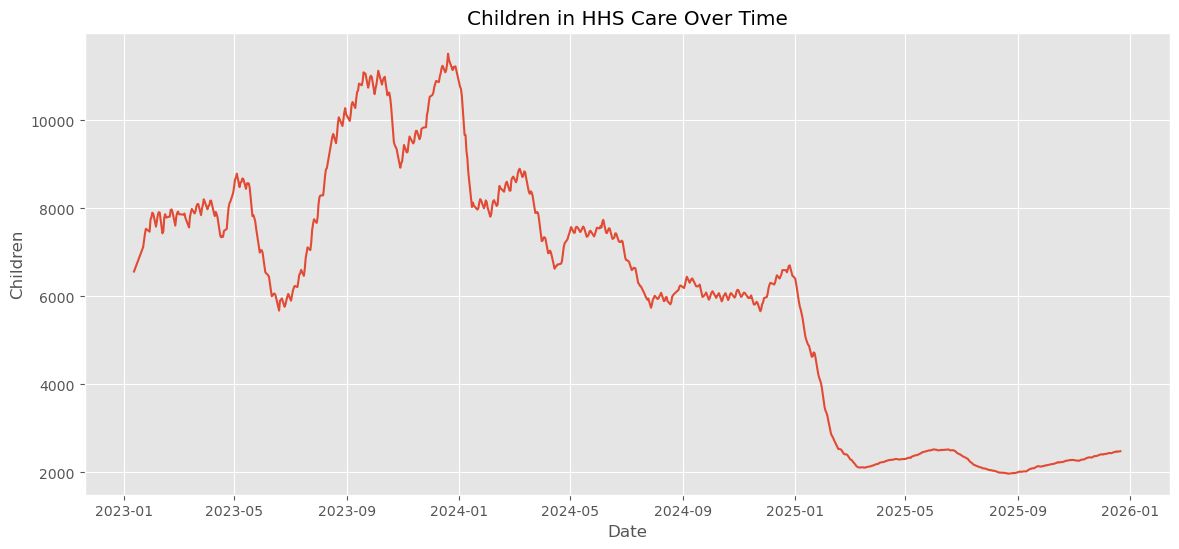

In [41]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df['Children in HHS Care'])

plt.title('Children in HHS Care Over Time')
plt.xlabel('Date')
plt.ylabel('Children')

plt.show()

In [42]:
print(df.dtypes)

Children apprehended and placed in CBP custody*    float64
Children in CBP custody                            float64
Children transferred out of CBP custody            float64
Children in HHS Care                               float64
Children discharged from HHS Care                  float64
dtype: object


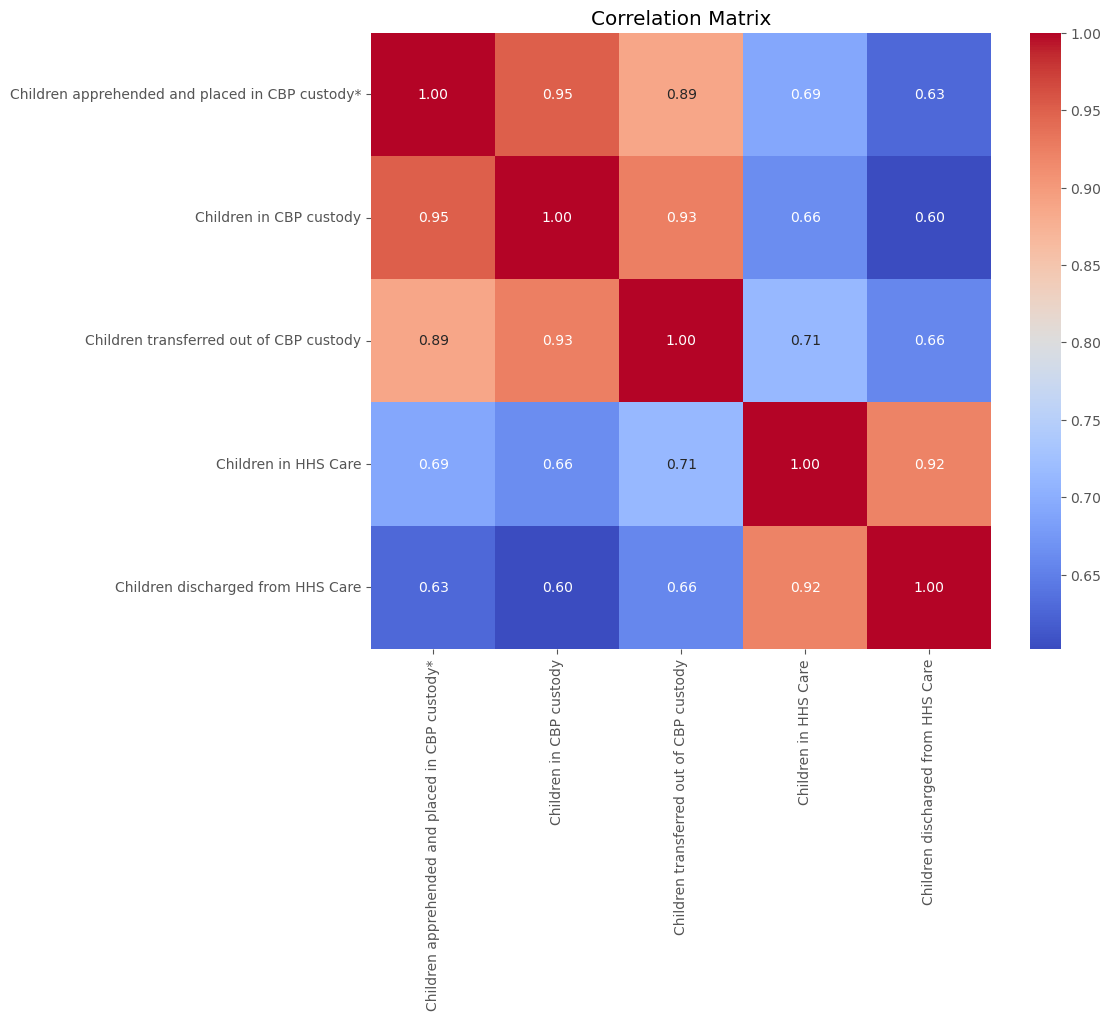

In [43]:
#Correlation Matrix
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

In [44]:
#Statistical Summary
df.describe()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
count,720.000000,720.000000,720.000000,720.000000,720.000000
mean,93.523611,171.494444,128.668056,6061.275000,173.406944
std,72.646625,126.354965,97.322012,2833.070109,125.702841
min,0.000000,7.000000,0.000000,1972.000000,0.000000
25%,12.000000,36.000000,14.000000,2467.750000,19.750000
50%,99.000000,193.000000,157.000000,6406.500000,181.000000
75%,147.250000,263.250000,199.250000,8010.250000,267.000000
max,333.000000,531.000000,440.000000,11516.000000,505.000000


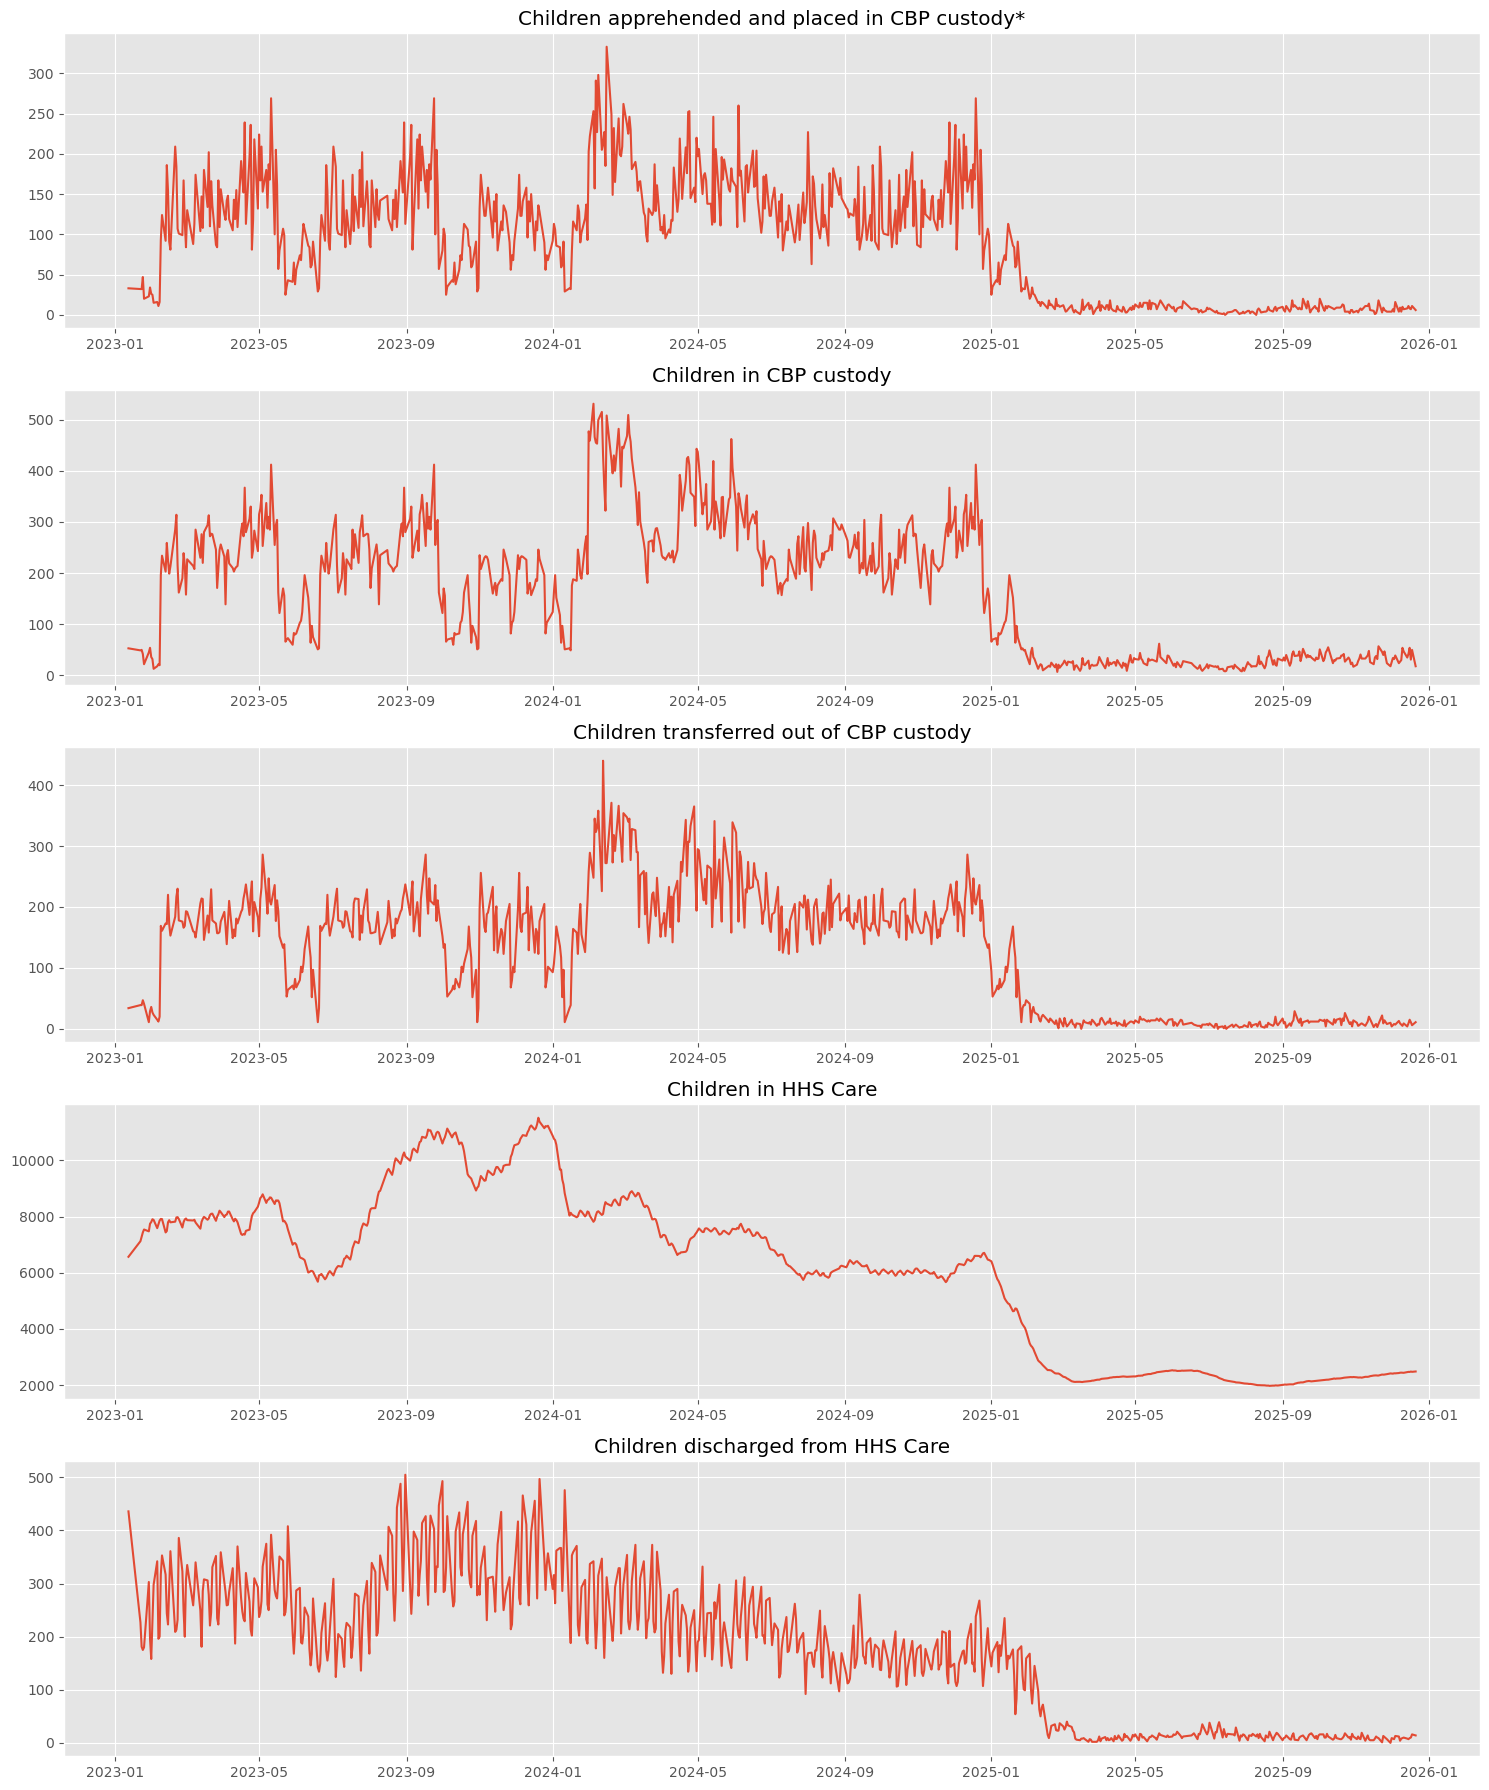

In [45]:
fig, axes = plt.subplots(5, 1, figsize=(15,18))

columns = df.columns

for i, col in enumerate(columns):
    axes[i].plot(df.index, df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

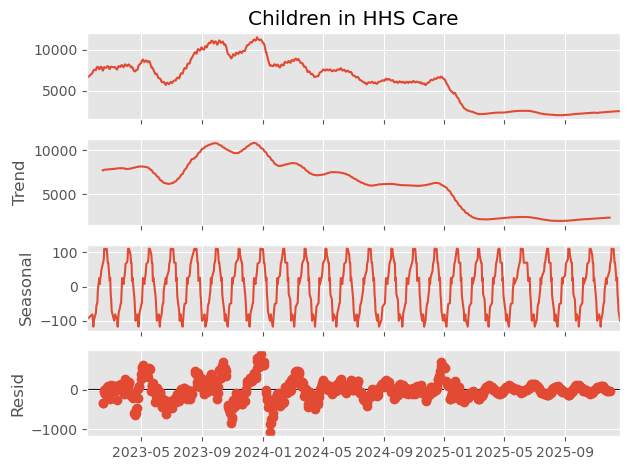

In [46]:
#Seasonal Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    df['Children in HHS Care'],
    model='additive',
    period=30
)

decomposition.plot()

plt.show()

In [47]:
df.to_csv(
    "../data/cleaned_uac_data.csv"
)